## Решение TSP методами GA (DEAP)

### Импорты

In [51]:
import random
import numpy as np
import matplotlib.pyplot as plt
from deap import base, creator, tools, algorithms
from functools import partial

### Генерация данных 2D

In [52]:
def generate_cities(n_cities: int):
    # Создаём N случайных городов на плоскости
    cities = np.random.rand(n_cities, 2) * 100  # координаты [x, y]

    # Матрица расстояний (евклидово расстояние)
    dist_matrix = np.zeros((n_cities, n_cities))
    for i in range(n_cities):
        for j in range(n_cities):
            dist_matrix[i][j] = np.linalg.norm(cities[i] - cities[j])
    return cities, dist_matrix

### Функция оптимизации (длина маршрута)

In [53]:
def evalTSP(individual, dist_matrix):
    # individual – список городов в порядке обхода
    distance = 0
    for i in range(len(individual)):
        from_city = individual[i]
        to_city = individual[(i+1) % len(individual)]  # замыкаем маршрут
        distance += dist_matrix[from_city][to_city]
    return distance

### Генетический алгоритм

In [54]:
def optimize_tsp(cities, dist_matrix, pop_size=300, ngen=200, cxpb=0.8, mutpb=0.2, mutindpb=0.05, tournsize=3):
    """_summary_

    Args:
        cities (_type_): _description_
        dist_matrix (_type_): _description_
        pop_size (_type_): размер популяции
        ngen (_type_): количество поколений
        cxpb (_type_): вероятность кроссовера
        mutpb (_type_): вероятность мутации
        mutindpb (_type_): вероятность мутации каждого отдельного элемента в особи
        tournsize (_type_): размер турнира

    Returns:
        _type_: _description_
    """
    n_cities = len(cities)

    # Создаём классы: максимизация приспособленности (но мы будем минимизировать,
    # поэтому используем weights=(-1.0,)) – чем меньше расстояние, тем лучше.
    if not hasattr(creator, "FitnessMin"):
        creator.create('FitnessMin', base.Fitness, weights=(-1.0,))
    if not hasattr(creator, "Individual"):
        creator.create('Individual', list, fitness=creator.FitnessMin) # особь = список городов

    toolbox = base.Toolbox()

    # Генератор случайной перестановки городов
    toolbox.register("indices", random.sample, range(n_cities), n_cities)
    toolbox.register("individual", tools.initIterate, creator.Individual, toolbox.indices)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    toolbox.register("evaluate", partial(evalTSP, dist_matrix=dist_matrix))

    # Для перестановок используем упорядоченный кроссовер (OX)
    toolbox.register("mate", tools.cxOrdered)
    # Мутация: инверсия случайного сегмента
    toolbox.register("mutate", tools.mutShuffleIndexes, indpb=mutindpb)
    # Отбор: турнирный (размер турнира 3)
    toolbox.register("select", tools.selTournament, tournsize=tournsize)

    # Создаём начальную популяцию
    pop = toolbox.population(n=pop_size)

    # Статистика для наблюдения за процессом
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("min", np.min)
    stats.register("max", np.max)

    # Используем простой алгоритм eaSimple (с элитизмом можно добавить)
    pop, logbook = algorithms.eaSimple(pop, toolbox, cxpb=cxpb, mutpb=mutpb,
                                    ngen=ngen, stats=stats, verbose=True)

    return pop, logbook

### Запуск эволюции

In [55]:
cities, dist_matrix = generate_cities(n_cities=20)

In [56]:
pop, logbook = optimize_tsp(cities=cities, dist_matrix=dist_matrix)

TypeError: object of type 'numpy.float64' has no len()

In [ ]:
# Извлекаем лучшую особь после эволюции
best = tools.selBest(pop, 1)[0]
best_distance = evalTSP(best, dist_matrix)[0]
print(f"\nЛучший маршрут: {best}")
print(f"Длина маршрута: {best_distance:.3f}")


Лучший маршрут: [14, 9, 8, 2, 18, 19, 10, 7, 0, 3, 12, 11, 6, 15, 16, 5, 1, 17, 4, 13]
Длина маршрута: 416.739


### Визуализация

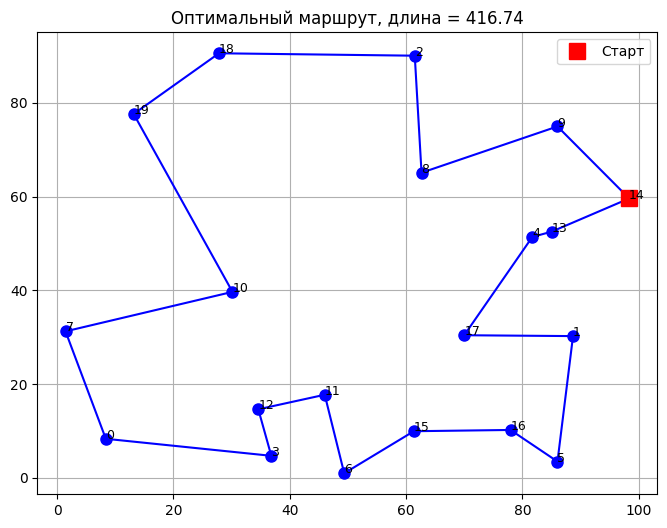

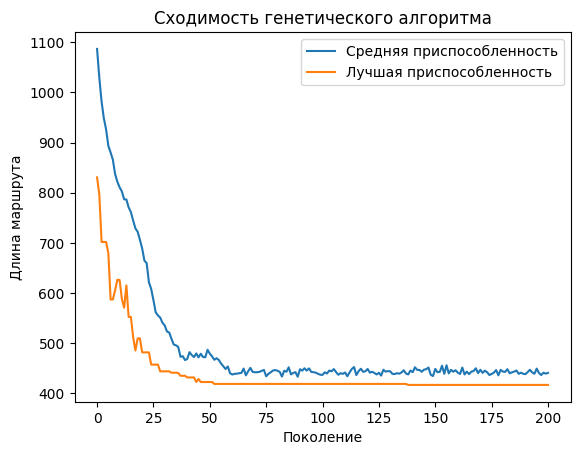

In [ ]:
def plot_route(route, cities):
    route_cities = cities[route]  # координаты в порядке маршрута
    # Замыкаем маршрут, добавляя первую точку в конец
    route_cities = np.vstack([route_cities, route_cities[0]])
    plt.figure(figsize=(8, 6))
    plt.plot(route_cities[:,0], route_cities[:,1], 'o-', color='blue', markersize=8)
    plt.plot(cities[route[0],0], cities[route[0],1], 'rs', markersize=12, label='Старт')
    for i, city in enumerate(cities):
        plt.text(city[0], city[1], str(i), fontsize=9)
    plt.title(f"Оптимальный маршрут, длина = {best_distance:.2f}")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_route(best, cities)

# Дополнительно: график сходимости
avg_fitness = logbook.select("avg")
min_fitness = logbook.select("min")
plt.figure()
plt.plot(avg_fitness, label="Средняя приспособленность")
plt.plot(min_fitness, label="Лучшая приспособленность")
plt.xlabel("Поколение")
plt.ylabel("Длина маршрута")
plt.legend()
plt.title("Сходимость генетического алгоритма")
plt.show()